In [3]:
import bs4 as bs
import urllib.request
import re
import nltk
import requests
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to C:\Users\Muhamad
[nltk_data]     Asqar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
url = 'https://en.wikipedia.org/wiki/Machine_learning'
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)
ml_wiki_parsed = bs.BeautifulSoup(response.text, 'lxml')

paragraphs = ml_wiki_parsed.find_all('p')
article_text = ""
for p in paragraphs:
    article_text += p.text

In [5]:
# Cleaing the text
ml_wiki_cleaned = article_text.lower()
ml_wiki_cleaned = re.sub('[^a-zA-Z]', ' ', ml_wiki_cleaned)
ml_wiki_cleaned = re.sub(r'\s+', ' ', ml_wiki_cleaned)

In [6]:
# Preparing the dataset
all_sentences = nltk.sent_tokenize(ml_wiki_cleaned)
all_words = [nltk.word_tokenize(sent) for sent in all_sentences]
# Removing Stop Words
from nltk.corpus import stopwords
for i in range(len(all_words)):
    all_words[i] = [w for w in all_words[i] if w not in stopwords.words('english')]

In [ ]:
from gensim.models import Word2Vec
skipgram = Word2Vec(all_words, vector_size=100, window=5, min_count=2, sg=1) #sg = 1 skip-gram, sg = 0 CBOW

In [ ]:
vocabulary = skipgram.wv.index_to_key
vocabulary

['learning',
 'machine',
 'data',
 'model',
 'training',
 'algorithms',
 'ai',
 'set',
 'used',
 'models',
 'artificial',
 'systems',
 'based',
 'methods',
 'also',
 'algorithm',
 'decision',
 'example',
 'classification',
 'neural',
 'examples',
 'input',
 'theory',
 'field',
 'supervised',
 'techniques',
 'many',
 'feature',
 'trained',
 'networks',
 'regression',
 'often',
 'compression',
 'called',
 'human',
 'unsupervised',
 'one',
 'output',
 'system',
 'knowledge',
 'network',
 'using',
 'intelligence',
 'rule',
 'new',
 'variables',
 'may',
 'research',
 'time',
 'analysis',
 'tasks',
 'like',
 'predictions',
 'function',
 'large',
 'process',
 'image',
 'problems',
 'linear',
 'performance',
 'statistical',
 'rules',
 'detection',
 'features',
 'known',
 'signal',
 'represented',
 'given',
 'reinforcement',
 'mining',
 'class',
 'deep',
 'perform',
 'biases',
 'typically',
 'method',
 'learned',
 'use',
 'include',
 'software',
 'e',
 'computer',
 'mathematical',
 'approaches'

In [ ]:
v1 = skipgram.wv['artificial']
v1

array([-0.173001  ,  0.07868786,  0.05913626, -0.02303088, -0.00945731,
       -0.26145568,  0.09656786,  0.3203882 , -0.17089526, -0.11506063,
       -0.13768157, -0.20814826, -0.03484411,  0.10742386,  0.11558443,
       -0.05675537, -0.02419296, -0.11378413, -0.09914356, -0.27645048,
        0.06625206,  0.04899125,  0.08992762, -0.12758476, -0.15354127,
        0.0168819 , -0.07499284, -0.04545889, -0.20065907, -0.05179389,
        0.18919604,  0.00364729,  0.02984161, -0.15105835, -0.07651545,
        0.19604002, -0.01165603, -0.15305609, -0.13300082, -0.22767897,
       -0.05191891, -0.15865588, -0.08333427, -0.04920349,  0.11592207,
       -0.0141039 , -0.09113234,  0.06281091,  0.03278195,  0.07548836,
        0.0577517 , -0.16183601, -0.06173597, -0.06911347, -0.03023588,
        0.0791611 ,  0.11171307,  0.03444282, -0.17082377,  0.04674388,
       -0.02067558,  0.0650149 ,  0.02047938, -0.03322219, -0.19658312,
        0.09729315,  0.11424865,  0.17896946, -0.2800611 ,  0.14

In [17]:
print("length of the vector representation is:" , len(v1))

length of the vector representation is: 100


In [ ]:
skipgram.wv.most_similar('artificial', topn=5)

[('learning', 0.9982737898826599),
 ('ai', 0.9981935024261475),
 ('models', 0.9980906844139099),
 ('based', 0.9980884194374084),
 ('systems', 0.9980415105819702)]

In [19]:
cbow = Word2Vec(all_words, vector_size=100, window=5, min_count=2, sg=0)

In [21]:
v2 = cbow.wv['artificial']
print("length of the vector representation is:" , len(v2))
v2

length of the vector representation is: 100


array([ 1.30260398e-03,  3.14297667e-03,  9.00655333e-03, -9.02500004e-03,
       -6.99799182e-03, -1.52387628e-02, -8.65406415e-04,  1.87524837e-02,
       -8.36218148e-03, -1.15726134e-02,  3.88478045e-03, -1.28748892e-02,
        6.82319701e-03, -2.19075265e-03,  6.19042525e-03,  9.12287447e-04,
        3.55298026e-03, -6.57655252e-03,  9.59333091e-04, -1.89961400e-02,
       -1.05365158e-04, -7.33228924e-04,  9.21823457e-03, -7.64063280e-03,
       -9.52722784e-03,  4.22944315e-03, -4.80647897e-03, -6.87108608e-03,
        1.40389823e-03,  3.74973449e-03,  2.85131671e-03,  2.07611383e-03,
        1.04265353e-02,  3.71874380e-03,  1.72995299e-03,  1.28114680e-02,
        3.37683526e-03, -9.06508602e-03, -1.15757789e-02, -9.45910532e-03,
       -3.18739982e-03, -5.37912687e-03, -8.24503787e-03,  6.06999639e-03,
       -1.83141197e-03, -9.34185553e-03, -5.88515447e-03, -7.26841739e-04,
       -4.22889879e-03,  2.93970783e-03, -3.09714070e-03, -8.20363872e-03,
       -8.58848356e-03, -

In [22]:
cbow.wv.most_similar('artificial', topn=5)

[('learning', 0.6268677115440369),
 ('ai', 0.5817103385925293),
 ('systems', 0.5601024031639099),
 ('machine', 0.5513753890991211),
 ('rule', 0.5381655693054199)]

## Visualization of trained model

In [23]:
text = "Ram was a king. He was the son of king Dasharatha. Sita, the daughter of king Jana was his queen."
all_sentences = nltk.sent_tokenize(text)
text_tokenised = [nltk.word_tokenize(sent) for sent in all_sentences]
print(text_tokenised)


[['Ram', 'was', 'a', 'king', '.'], ['He', 'was', 'the', 'son', 'of', 'king', 'Dasharatha', '.'], ['Sita', ',', 'the', 'daughter', 'of', 'king', 'Jana', 'was', 'his', 'queen', '.']]


In [29]:
word2vec = Word2Vec(text_tokenised, min_count=1, vector_size = 3, window=3)
word2vec.wv['king']

array([ 0.30024454, -0.30997968, -0.23721655], dtype=float32)

In [30]:
v1 = word2vec.wv['Ram']
print("length of the vector representation is:" , len(v1))
print(v1)

length of the vector representation is: 3
[-0.00987271 -0.25537467  0.32049143]


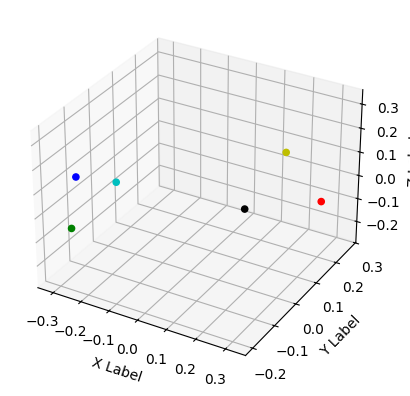

In [34]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
x =[word2vec.wv['Ram'],word2vec.wv['king']]
y =[word2vec.wv['son'],word2vec.wv['daughter']]
z =[word2vec.wv['Sita'] ,word2vec.wv['queen'] ]
ax.scatter(x,y,z, c=['k', 'g' , 'y' , 'r' ,'b' ,'c'] , depthshade = False )
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')
plt.show()

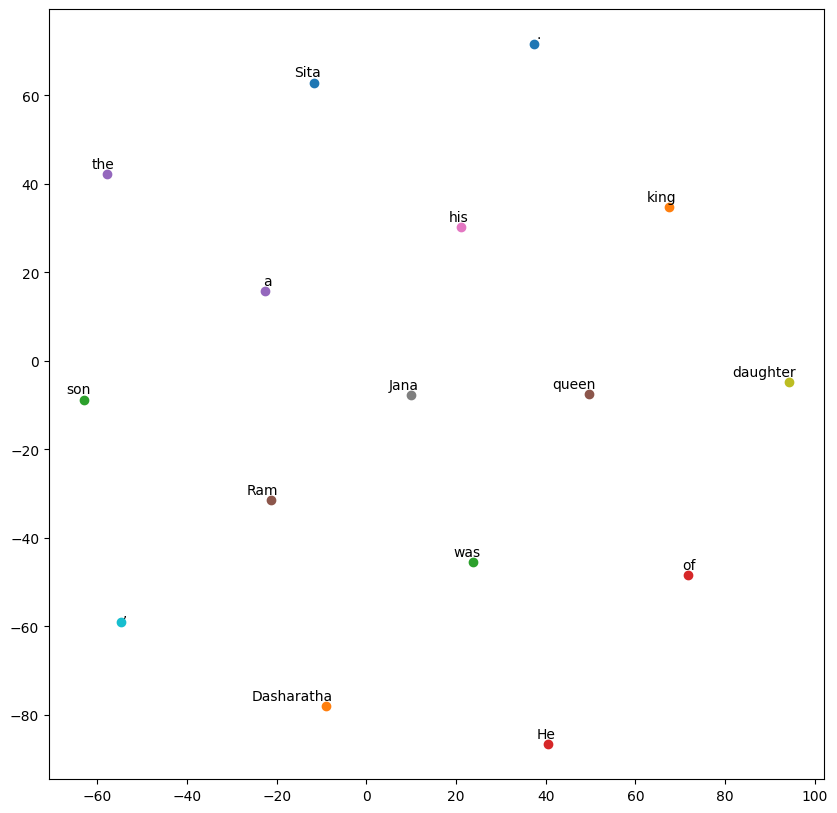

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
%matplotlib inline


def tsne_plot(model):
    labels = []
    tokens = []

    for word in model.wv.index_to_key:
        tokens.append(model.wv[word])
        labels.append(word)

    tokens_array = np.array(tokens)

    num_samples = tokens_array.shape[0]
    safe_perplexity = min(40, max(5, num_samples - 1))

    tsne_model = TSNE(
        perplexity=safe_perplexity,  # Prevents value errors on small datasets
        n_components=2,
        init="pca",
        n_iter=2500,
        random_state=23,
    )
    new_values = tsne_model.fit_transform(tokens_array)

    x = []
    y = []
    for value in new_values:
        x.append(value[0])
        y.append(value[1])

    plt.figure(figsize=(10, 10))
    for i in range(len(x)):
        plt.scatter(x[i], y[i])
        plt.annotate(
            labels[i],
            xy=(x[i], y[i]),
            xytext=(5, 2),
            textcoords="offset points",
            ha="right",
            va="bottom",
        )
    plt.show()
tsne_plot(word2vec)